In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import os

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [2]:
import random
import numpy as np
import tensorflow as tf

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

In [3]:
df = pd.read_csv("../../data/diabetes.csv")

print(df.shape)

df.head()

(768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
batch_size = len(df) // 10

batches = []

for i in range(10):

    start = i * batch_size

    if i == 9:
        batch = df.iloc[start:]
    else:
        batch = df.iloc[start:start + batch_size]

    batches.append(batch)

print("Number of batches:", len(batches))

Number of batches: 10


In [5]:
results = []

In [6]:
all_false_negatives = []         
for i in range(3, 8):

    print(f"Processing Window {i}")

    # Last 3 batches
    window = pd.concat([
        batches[i-3],
        batches[i-2],
        batches[i-1]
    ])

    # Rolling features
    rolling_mean = window.mean(numeric_only=True)

    rolling_std = window.std(numeric_only=True)

    trend = (
        batches[i-1].mean(numeric_only=True)
        -
        batches[i-3].mean(numeric_only=True)
    )

    # Predict future batch
    future_batch = batches[i+1]

    X_train = window.drop("Outcome", axis=1)
    y_train = window["Outcome"]

    X_future = future_batch.drop("Outcome", axis=1)
    y_future = future_batch["Outcome"]

    scaler = MinMaxScaler()

    X_train = scaler.fit_transform(X_train)

    X_future = scaler.transform(X_future)

    model = tf.keras.Sequential([

        tf.keras.layers.Dense(
            64,
            activation="relu",
            input_shape=(X_train.shape[1],)
        ),

        tf.keras.layers.Dense(
            32,
            activation="relu"
        ),

        tf.keras.layers.Dense(
            1,
            activation="sigmoid"
        )

    ])

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    model.fit(
        X_train,
        y_train,
        epochs=20,
        batch_size=32,
        verbose=0
    )

    y_prob = model.predict(
        X_future,
        verbose=0
    )

    thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]

    best_f1 = 0
    best_threshold = 0.5

    for threshold in thresholds:

        y_pred = (y_prob > threshold).astype(int)

        current_f1 = f1_score(
            y_future,
            y_pred,
            zero_division=0
        )

        if current_f1 > best_f1:

            best_f1 = current_f1
            best_threshold = threshold

    y_pred = (
        y_prob > best_threshold
    ).astype(int)

    batch_fn = future_batch.copy()
    batch_fn["predicted"] = y_pred.flatten()
    batch_fn = batch_fn[(batch_fn["Outcome"] == 1) & (batch_fn["predicted"] == 0)]
    batch_fn["window"] = i
    all_false_negatives.append(batch_fn)

    acc = accuracy_score(
        y_future,
        y_pred
    )

    precision = precision_score(
        y_future,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_future,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_future,
        y_pred,
        zero_division=0
    )

    results.append([
        i,
        acc,
        precision,
        recall,
        f1,
        best_threshold
    ])

false_negatives_df = pd.concat(all_false_negatives, ignore_index=True)
false_negatives_df.to_csv("../../results/week5/false_negatives.csv", index=False)
false_negatives_df

Processing Window 3


c:\Users\neeli\OneDrive\Desktop\disease-ai-intern\.venv311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Processing Window 4


c:\Users\neeli\OneDrive\Desktop\disease-ai-intern\.venv311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Processing Window 5


...

Processing Window 6


c:\Users\neeli\OneDrive\Desktop\disease-ai-intern\.venv311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Processing Window 7


c:\Users\neeli\OneDrive\Desktop\disease-ai-intern\.venv311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,predicted,window
0,3,112,74,30,0,31.6,0.197,25,1,0,3
1,0,124,70,20,0,27.4,0.254,36,1,0,3
2,2,102,86,36,120,45.5,0.127,23,1,0,3
3,5,0,80,32,0,41.0,0.346,37,1,0,3
4,0,131,66,40,0,34.3,0.196,22,1,0,4
5,4,95,64,0,0,32.0,0.161,31,1,0,4
6,5,136,84,41,88,35.0,0.286,35,1,0,4
7,0,138,60,35,167,34.6,0.534,21,1,0,4
8,3,173,84,33,474,35.7,0.258,22,1,0,4
9,3,129,64,29,115,26.4,0.219,28,1,0,4


In [7]:
results_df = pd.DataFrame(

    results,

    columns=[
        "Window",
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "Threshold"
    ]

)

results_df

,Window,Accuracy,Precision,Recall,F1,Threshold
0,3,0.657895,0.521739,0.857143,0.648649,0.3
1,4,0.671053,0.555556,0.689655,0.615385,0.4
2,5,0.736842,0.350000,0.500000,0.411765,0.5
3,6,0.513158,0.365385,0.826087,0.506667,0.3
4,7,0.750000,0.583333,0.840000,0.688525,0.3


In [8]:
print(results_df)

print("\nNumber of Rows:", len(results_df))

   Window  Accuracy  Precision    Recall        F1  Threshold
0       3  0.657895   0.521739  0.857143  0.648649        0.3
1       4  0.671053   0.555556  0.689655  0.615385        0.4
2       5  0.736842   0.350000  0.500000  0.411765        0.5
3       6  0.513158   0.365385  0.826087  0.506667        0.3
4       7  0.750000   0.583333  0.840000  0.688525        0.3

Number of Rows: 5


In [ ]:
os.makedirs(
    "../results/week5",
    exist_ok=True
)

results_df.to_csv(
    "../results/week5/proactive_results.csv",
    index=False
)

print("CSV Saved")

CSV Saved


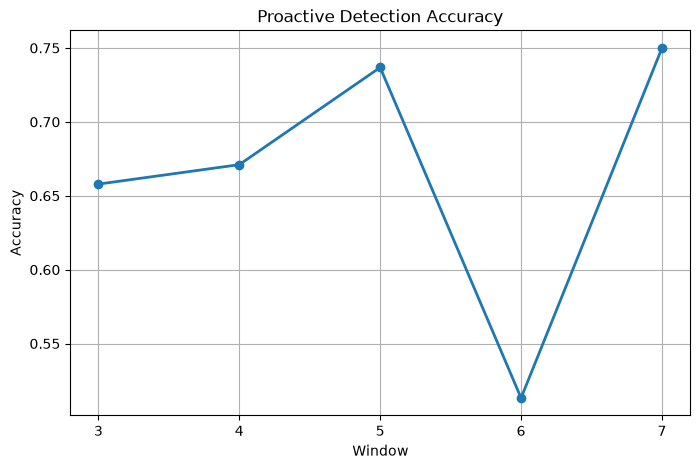

In [10]:
plt.figure(figsize=(8,5))

plt.plot(
    results_df["Window"],
    results_df["Accuracy"],
    marker="o",
    linewidth=2
)

plt.xticks(results_df["Window"])

plt.grid(True)

plt.title("Proactive Detection Accuracy")

plt.xlabel("Window")

plt.ylabel("Accuracy")

plt.savefig(
    "../results/week5/proactive_accuracy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

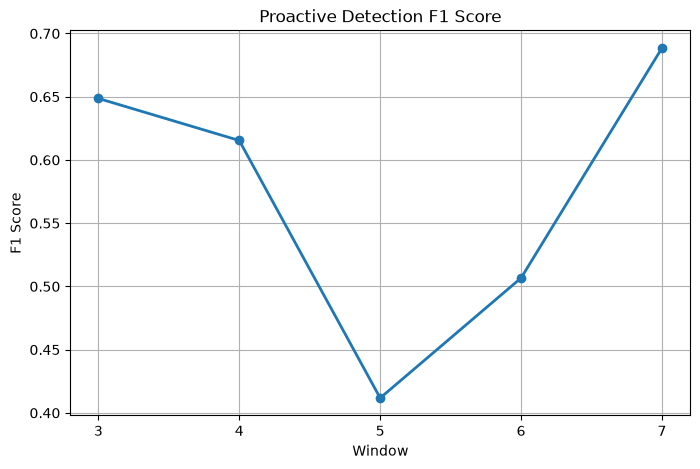

In [11]:
plt.figure(figsize=(8,5))

plt.plot(
    results_df["Window"],
    results_df["F1"],
    marker="o",
    linewidth=2
)

plt.xticks(results_df["Window"])

plt.grid(True)

plt.title("Proactive Detection F1 Score")

plt.xlabel("Window")

plt.ylabel("F1 Score")

plt.savefig(
    "../results/week5/proactive_f1.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [12]:
results_df.sort_values(
    by="F1",
    ascending=False
)

,Window,Accuracy,Precision,Recall,F1,Threshold
4,7,0.750000,0.583333,0.840000,0.688525,0.3
0,3,0.657895,0.521739,0.857143,0.648649,0.3
1,4,0.671053,0.555556,0.689655,0.615385,0.4
3,6,0.513158,0.365385,0.826087,0.506667,0.3
2,5,0.736842,0.350000,0.500000,0.411765,0.5
